Using bandpass 3095.0–4095.0 Hz


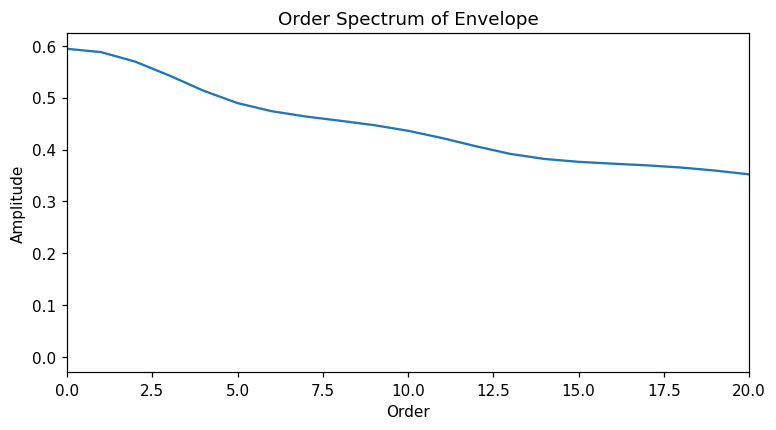

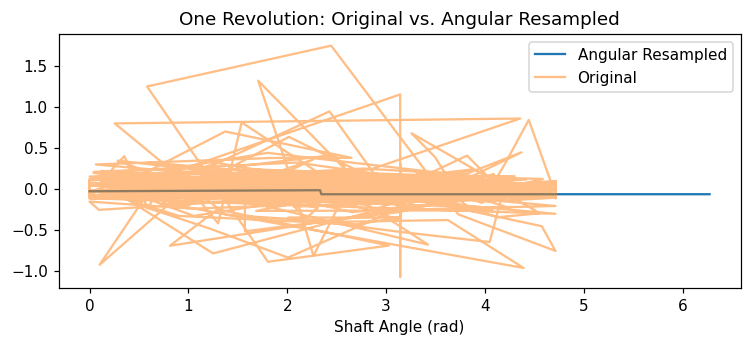

In [35]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt

# User's helper to load data
from brf_lightning.data.bearing.utils import load_vibration_data

# ── Parameters ────────────────────────────────────────────────────────
BASE_DIR = Path("data/bearing_thl_v1")
N_ORD_SAMPLES = 512   # samples per revolution for angular resampling
NFFT = 4096           # FFT length for order spectrum

# ── Load one example file ─────────────────────────────────────────────
fp = sorted(BASE_DIR.glob("*.csv"))[3]
df, fs = load_vibration_data(fp)
x = df["sensor_bearing"].values.astype(np.float32)
trig = df["trig"].values.astype(int)
t = np.arange(len(x)) / fs

# ── 1) Build phase map using trig (4 pulses per rev) ───────────────────
# find indices of each pulse
idx = np.flatnonzero(trig == 1)
# only keep full groups of 4 pulses
n_full = (idx.size // 4) * 4
idx    = idx[:n_full]
# we assume idx groups into revs of 4 rising edges
revs = idx.reshape(-1, 4)
# assign angles 0, π/2, π, 3π/2 for each measured pulse
phi_meas = np.tile([0, np.pi/2, np.pi, 3*np.pi/2], revs.shape[0])
t_meas = revs.ravel() / fs
# interpolate to full time axis
phi_t = np.interp(t, t_meas, phi_meas, period=2*np.pi)

# ── 2) Angular resampling per revolution ───────────────────────────────
phi_target = np.linspace(0, 2*np.pi, N_ORD_SAMPLES, endpoint=False)
resampled = []
for k in range(revs.shape[0]-1):
    start, end = revs[k,0], revs[k+1,0]
    seg_x = x[start:end]
    seg_phi = phi_t[start:end]
    # interpolate onto uniform angle grid
    x_ang = np.interp(phi_target, seg_phi, seg_x)
    resampled.append(x_ang)
resampled = np.vstack(resampled)

# ── 3) Envelope (optional) ― narrowband around a reaction peak ─────────
# Suppose your SK step gave you f_lo and f_hi in Hz; here just examples:
f_lo, f_hi = 4500.0, 5500.0

# 1) Clamp both edges into (0, fs/2)
f_lo = max(f_lo, 1.0)
f_hi = min(f_hi, fs*0.5 - 1.0)

# 2) If that’s inverted, shrink or fallback to a broad band
if f_lo >= f_hi:
    # try shrinking the low edge to 1 kHz below f_hi
    f_lo = max(1.0, f_hi - 1000.0)
    if f_lo >= f_hi:
        # ultimate fallback:
        print("⚠️ SK band invalid after clamp; using [100 Hz → Nyquist].")
        f_lo, f_hi = 100.0, fs*0.5 - 1.0

# 3) Design a Butterworth in real Hz
sos = sig.butter(
    4,
    [f_lo, f_hi],       # these are in Hz
    btype='bandpass',
    output='sos',
    fs=fs               # SciPy will normalize internally
)
print(f"Using bandpass {f_lo:.1f}–{f_hi:.1f} Hz")

# 4) Apply filter + Hilbert per revolution
env = sig.sosfiltfilt(sos, resampled, axis=1)
env = np.abs(sig.hilbert(env, axis=1))

# ── 4) Compute and plot order spectrum ─────────────────────────────────
spec = np.fft.rfft(env, axis=1, n=NFFT)
order_bins = np.arange(spec.shape[1])
order_spec = np.mean(np.abs(spec), axis=0)

plt.figure(figsize=(8,4))
plt.plot(order_bins, order_spec)
plt.title("Order Spectrum of Envelope")
plt.xlabel("Order")
plt.ylabel("Amplitude")
plt.xlim(0, 20)  # e.g., first 20 orders
plt.show()

# Displaying the resampled and original trace alignment for one rev
plt.figure(figsize=(8,3))
plt.plot(phi_target, resampled[0], label="Angular Resampled")
plt.plot(phi_t[revs[0,0]:revs[1,0]], x[revs[0,0]:revs[1,0]], alpha=0.5, label="Original")
plt.legend()
plt.title("One Revolution: Original vs. Angular Resampled")
plt.xlabel("Shaft Angle (rad)")
plt.show()


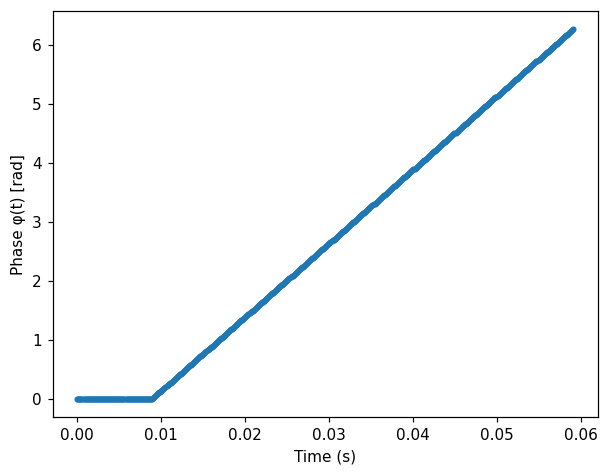

In [36]:
# preallocate
phi_t = np.zeros(len(x), dtype=float)

# for each revolution (except the last partial one)
for (s0, s1) in zip(revs[:-1,0], revs[1:,0]):
    L = s1 - s0
    # linearly ramp 0 → 2π over the samples in [s0, s1)
    phi_t[s0:s1] = np.linspace(0, 2*np.pi, L, endpoint=False)

# (optional) fill the tail beyond the last full rev with whatever you like,
# e.g. repeat the final ramp or leave as zeros
# sanity check: plot φ(t) for first 2 revolutions
plt.plot(t[:revs[1,0]], phi_t[:revs[1,0]], '.-')
plt.xlabel('Time (s)')
plt.ylabel('Phase φ(t) [rad]')
plt.show()


Loaded fIII20.csv with 4915200 samples at 8192.0 Hz.


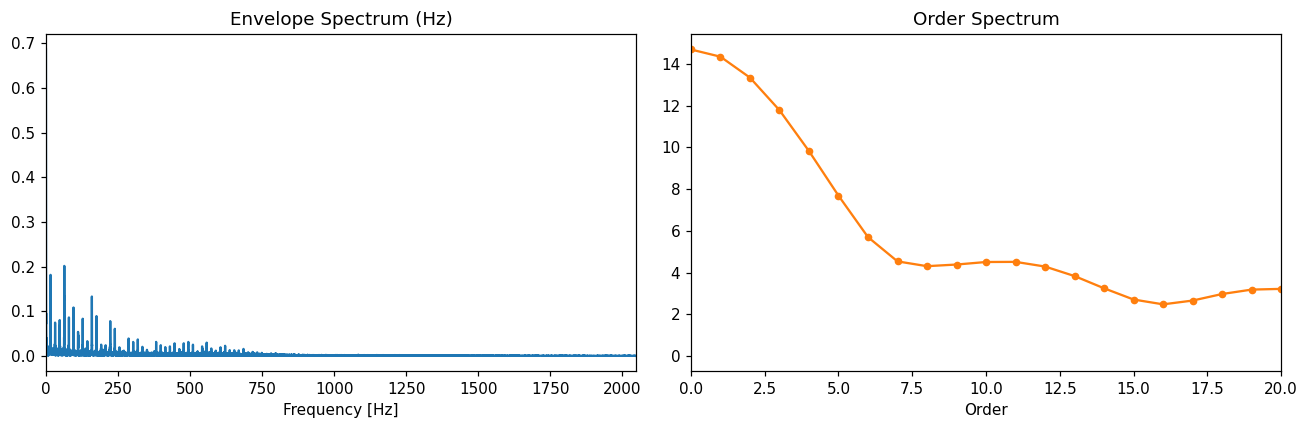

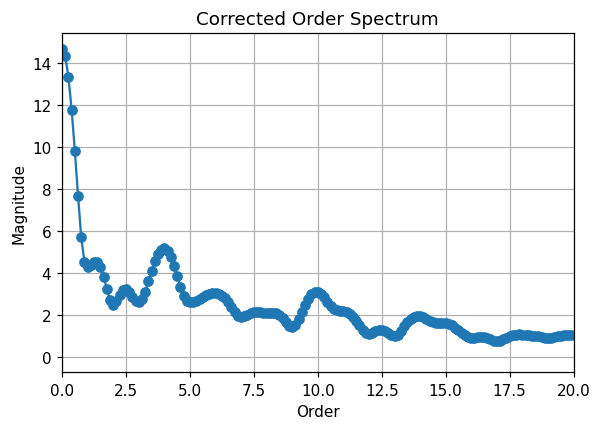

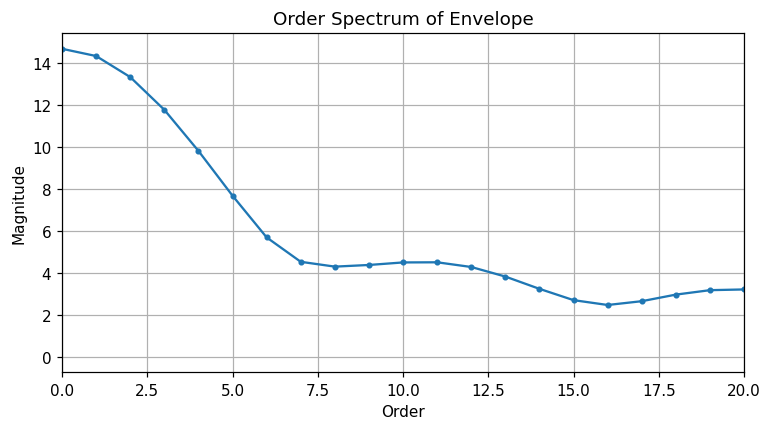

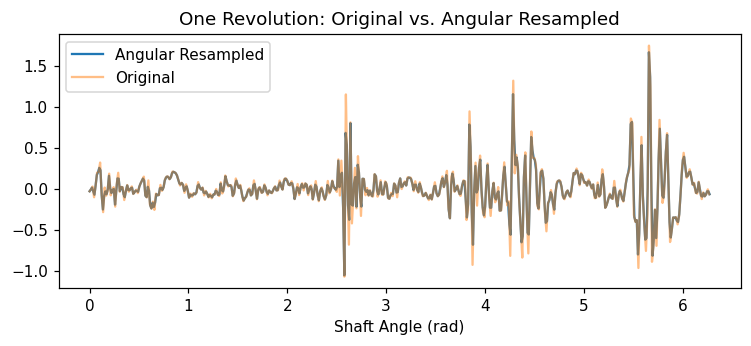

In [46]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt

# ── 0) User helper to load a CSV with columns "sensor_bearing" and "TRIG"
from brf_lightning.data.bearing.utils import load_vibration_data

plt.rcParams['figure.dpi'] = 110

# ── Parameters ────────────────────────────────────────────────────────
BASE_DIR       = Path("data/bearing_thl_v1")  # your data folder
N_ORD_SAMPLES  = 512                         # samples per revolution
NFFT           = 4096                        # FFT length for the order spectrum
# If you want the envelope, pick your filter band (e.g. from SK)
f_lo, f_hi     = 4500.0, 5500.0               # example resonance band (Hz)

# ── 1) Load one example file ─────────────────────────────────────────────
fp = sorted(BASE_DIR.glob("*.csv"))[4]
df, fs = load_vibration_data(fp)              # returns df, sampling rate fs
x    = df["sensor_bearing"].values.astype(np.float32)
trig = df["trig"].values.astype(int)
t    = np.arange(len(x)) / fs
print(f"Loaded {fp.name} with {len(x)} samples at {fs} Hz.")

# ── 2) Build a clean sawtooth phase φ(t) using TRIG (4 pulses/rev) ────────
idx = np.flatnonzero(trig == 1)
n_full = (idx.size // 4) * 4
idx = idx[:n_full]
revs = idx.reshape(-1, 4)                     # each row = indices of one rev
phi_t = np.zeros_like(x, dtype=float)

# Fill φ from 0→2π each rev
for s0, s1 in zip(revs[:-1,0], revs[1:,0]):
    L = s1 - s0
    phi_t[s0:s1] = np.linspace(0, 2*np.pi, L, endpoint=False)

# ── 3) Angular resample each rev onto uniform angle bins ────────────────
phi_bins = np.linspace(0, 2*np.pi, N_ORD_SAMPLES, endpoint=False)
resampled = []
for s0, s1 in zip(revs[:-1,0], revs[1:,0]):
    seg_x   = x[s0:s1]
    seg_phi = phi_t[s0:s1]
    x_ang   = np.interp(phi_bins, seg_phi, seg_x)
    resampled.append(x_ang)
resampled = np.vstack(resampled)  # shape = (n_revs, N_ORD_SAMPLES)

# ── (Optional) 4) Envelope‐demodulate in a narrow band ───────────────────
# 4a) clamp f_lo/f_hi to valid range
f_lo = max(f_lo, 1.0)
f_hi = min(f_hi, fs*0.5 - 1.0)
# 4b) if they cross, fallback to broad band
if f_lo >= f_hi:
    f_lo = max(1.0, f_hi - 1000.0)
    if f_lo >= f_hi:
        print("⚠️ SK band invalid; using [100 Hz → Nyquist].")
        f_lo, f_hi = 100.0, fs*0.5 - 1.0
# 4c) design Butterworth in Hz
sos = sig.butter(
    4,
    [f_lo, f_hi],
    btype='bandpass',
    output='sos',
    fs=fs
)
# 4d) apply per revolution
env = sig.sosfiltfilt(sos, resampled, axis=1)
env = np.abs(sig.hilbert(env, axis=1))

# ── A) Standard envelope spectrum (time-domain) ───────────────────────
# env is shaped (n_revs, N_ORD_SAMPLES); flatten back to 1D by concatenating
env_all = env.ravel()

# FFT in Hz
Nfft_env = 65536
spec_env = np.abs(np.fft.rfft(env_all * np.hanning(len(env_all)), n=Nfft_env))
f_hz     = np.fft.rfftfreq(Nfft_env, d=1/fs)

# ── B) Order spectrum (we already have) ─────────────────────────────────
# order_spec, order_bins from your previous code

# ── C) Plot comparison ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

ax1.plot(f_hz, spec_env, color='C0')
ax1.set_title("Envelope Spectrum (Hz)")
ax1.set_xlabel("Frequency [Hz]")
ax1.set_xlim(0, fs/4)

ax2.plot(order_bins, order_spec, color='C1', marker='o', ms=4)
ax2.set_title("Order Spectrum")
ax2.set_xlabel("Order")
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()


# ── 5) FFT → Order Spectrum ──────────────────────────────────────────────
# choose input = resampled (no envelope) or env (with envelope)
Y = np.fft.rfft(env, n=NFFT, axis=1)
order_bins = np.arange(Y.shape[1])
order_spec = np.mean(np.abs(Y), axis=0)

# M = number of angle‐samples per rev
M = resampled.shape[1]           # e.g. 512
# NFFT = length of your FFT (zero‐padding)
# Y.shape[1] = NFFT//2+1

order_axis = np.arange(Y.shape[1]) * (M / NFFT)
order_spec = np.mean(np.abs(Y), axis=0)

plt.figure(figsize=(6,4))
plt.plot(order_axis, order_spec, marker='o')
plt.xlim(0,20)
plt.xlabel("Order")
plt.ylabel("Magnitude")
plt.title("Corrected Order Spectrum")
plt.grid(True)
plt.show()


# ── 6) Plot Order Spectrum ───────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(order_bins, order_spec, '-o', ms=3)
plt.title("Order Spectrum of Envelope")
plt.xlabel("Order")
plt.ylabel("Magnitude")
plt.xlim(0, 20)
plt.grid(True)
plt.show()

# ── 7) Sanity‐check: one revolution alignment ─────────────────────────────
s0, s1 = revs[0,0], revs[1,0]
x_ang   = np.interp(phi_bins, phi_t[s0:s1], x[s0:s1])

plt.figure(figsize=(8,3))
plt.plot(phi_bins, x_ang, label="Angular Resampled")
plt.plot(phi_t[s0:s1], x[s0:s1], alpha=0.5, label="Original")
plt.legend()
plt.title("One Revolution: Original vs. Angular Resampled")
plt.xlabel("Shaft Angle (rad)")
plt.show()


In [49]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt
from brf_lightning.data.bearing.utils import load_vibration_data
from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band

plt.rcParams["figure.dpi"] = 110

# ── CONFIG ───────────────────────────────────────────────────────────────
BASE_DIR       = Path("data/bearing_thl_v1")
N_ORD_SAMPLES  = 512          # angle‐bins per revolution
NFFT_ORDER     = 4096         # FFT length for order–spectrum
NFFT_ENV       = 65536        # FFT length for envelope spectrum
WINDOW_ENV     = np.hanning  # window for env‐FFT
NPERSEG_STFT   = 8192         # for spectral kurtosis
BANDWIDTH_HZ   = 2000.0       # SK search bandwidth
MIN_FREQ_HZ    = 100.0        # SK min freq
MAX_RATIO_NQ   = 0.95         # SK max ratio Nyquist

# ── HELPERS ──────────────────────────────────────────────────────────────
speed_re  = re.compile(r"(\d+)\.csv$")
defect_re = re.compile(r"^(n|fAII|fIII)")

def parse_filename(fp):
    name = fp.stem
    speed = float(speed_re.search(fp.name).group(1))
    defect = defect_re.match(name).group(1)
    return defect, speed

def build_phase_map(trig, fs):
    """Return phi_t array of length len(trig) ramping 0→2π each full rev."""
    idx = np.flatnonzero(trig==1)
    n_full = (idx.size//4)*4
    idx = idx[:n_full]
    revs = idx.reshape(-1,4)
    phi_t = np.zeros(len(trig), float)
    for s0,s1 in zip(revs[:-1,0], revs[1:,0]):
        L = s1-s0
        phi_t[s0:s1] = np.linspace(0, 2*np.pi, L, endpoint=False)
    return phi_t, revs

def angular_resample(x, phi_t, revs, M=N_ORD_SAMPLES):
    """Resample each rev onto M uniform angle bins → (n_revs, M) array."""
    phi_bins = np.linspace(0, 2*np.pi, M, endpoint=False)
    out = []
    for s0,s1 in zip(revs[:-1,0], revs[1:,0]):
        seg_x   = x[s0:s1]
        seg_phi = phi_t[s0:s1]
        out.append(np.interp(phi_bins, seg_phi, seg_x))
    return np.vstack(out)

def envelope_angle(resampled, fs, f_lo, f_hi):
    """Filter in Hz then Hilbert‐envelope per row."""
    # clamp
    f_lo = max(f_lo, 1.0)
    f_hi = min(f_hi, fs*0.5 - 1.0)
    if f_lo >= f_hi:
        # shrink or fallback
        f_lo = max(1.0, f_hi-1000)
        if f_lo >= f_hi:
            f_lo, f_hi = 100.0, fs*0.5 - 1.0
    sos = sig.butter(4, [f_lo, f_hi], btype='bandpass', fs=fs, output='sos')
    y = sig.sosfiltfilt(sos, resampled, axis=1)
    return np.abs(sig.hilbert(y, axis=1))

def compute_env_spectrum(env):
    """Flatten all revs → envelope spectrum in Hz."""
    flat = env.ravel() * WINDOW_ENV(env.size)
    spec = np.abs(np.fft.rfft(flat, n=NFFT_ENV))
    freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
    return freqs, spec

def compute_order_spectrum(env, M=N_ORD_SAMPLES):
    """FFT each rev → mean order spectrum. Returns (orders, spec)."""
    Y = np.fft.rfft(env, n=NFFT_ORDER, axis=1)
    # rescale bins→orders
    order_axis = np.arange(Y.shape[1]) * (M/NFFT_ORDER)
    spec = np.mean(np.abs(Y), axis=0)
    return order_axis, spec

def find_peak(freqs, spec, center, window=0.2):
    """Find peak freq in ±window*center around center."""
    lo, hi = center*(1-window), center*(1+window)
    idx = np.flatnonzero((freqs>=lo)&(freqs<=hi))
    i_peak = idx[np.argmax(spec[idx])]
    return freqs[i_peak], spec[i_peak]

# ── ANALYSIS PER FILE ────────────────────────────────────────────────────
results = []
for fp in sorted(BASE_DIR.glob("*.csv")):
    defect, speed = parse_filename(fp)
    df, fs = load_vibration_data(fp)
    x   = df["sensor_bearing"].values.astype(np.float32)
    trig= df["trig"].values.astype(int)

    # 1) make phase map
    phi_t, revs = build_phase_map(trig, fs)

    # 2) angular resample
    res = angular_resample(x, phi_t, revs)

    # 3) SK band
    f, sk  = spectral_kurtosis(x, fs, nperseg=NPERSEG_STFT)
    f_lo, f_hi = max_sk_band(f, sk, bandwidth=BANDWIDTH_HZ, min_freq=MIN_FREQ_HZ, max_ratio=MAX_RATIO_NQ)

    # 4) envelope in angle domain
    env = envelope_angle(res, fs, f_lo, f_hi)

    # 5) envelope spectrum (Hz)
    freqs, env_spec = compute_env_spectrum(env)

    # 6) order spectrum
    orders, ord_spec = compute_order_spectrum(env, M=res.shape[1])

    # 7) locate peaks
    # roughly defect order = f_defect_Hz / speed
    # we use the max in the first 20 orders
    meas_order,  mag_ord = find_peak(orders, ord_spec, center=5.0, window=0.5)
    meas_freq,  mag_env = find_peak(freqs,  env_spec, center=meas_order*speed, window=0.2)

    results.append({
        "file":      fp.name,
        "defect":    defect,
        "speed_Hz":  speed,
        "meas_Hz":   meas_freq,
        "mag_env":   mag_env,
        "meas_ord":  meas_order,
        "mag_ord":   mag_ord,
    })

# ── Tabulate ─────────────────────────────────────────────────────────────
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))


      file defect  speed_Hz  meas_Hz  mag_env  meas_ord   mag_ord
fAII10.csv   fAII      10.0   30.000 0.034316      3.25  1.873812
fAII20.csv   fAII      20.0   48.375 0.683736      3.00 20.058291
fAII30.csv   fAII      30.0   96.875 0.571296      3.00 32.789180
fIII10.csv   fIII      10.0   21.875 0.128045      2.50  6.901962
fIII20.csv   fIII      20.0   79.750 0.716468      4.00 30.295529
fIII30.csv   fIII      30.0  111.625 0.396513      4.00 67.157804
   n10.csv      n      10.0   24.125 0.017647      2.50  1.086483
   n20.csv      n      20.0   50.125 0.039809      2.50  2.255598
   n30.csv      n      30.0   65.500 0.021233      2.50  3.098989


      file defect  speed_Hz  theo_order  meas_order  mag_order  meas_Hz  mag_env
fAII10.csv   fAII      10.0        4.95       3.250   1.873812   30.000 0.034316
fAII20.csv   fAII      20.0        4.95       3.000  20.058291   48.375 0.683736
fAII30.csv   fAII      30.0        4.95       3.000  32.789180   96.875 0.571296
fIII10.csv   fIII      10.0        3.05       2.375   7.092069   21.875 0.128045
fIII20.csv   fIII      20.0        3.05       4.000  30.295529   79.750 0.716468
fIII30.csv   fIII      30.0        3.05       4.000  67.157804  111.625 0.396513
   n10.csv      n      10.0        1.00       0.625   1.927208    6.000 0.019108
   n20.csv      n      20.0        1.00       0.625   9.002502   13.875 0.025162
   n30.csv      n      30.0        1.00       0.625  12.469281   16.000 0.026223


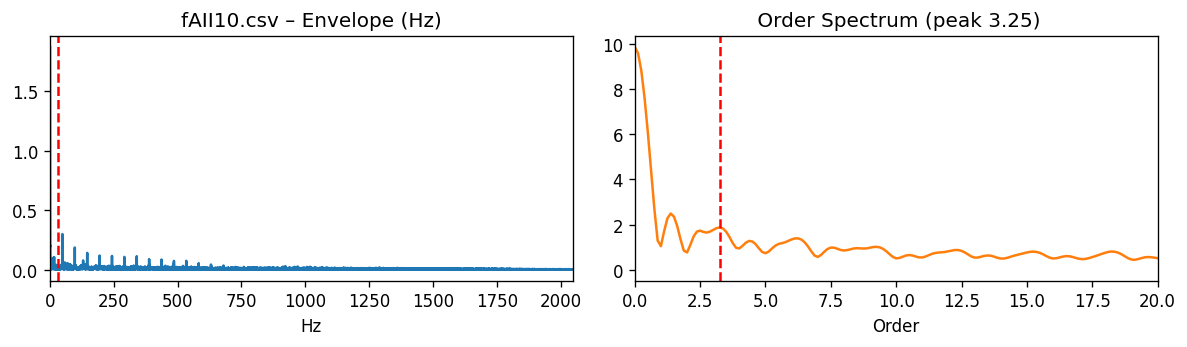

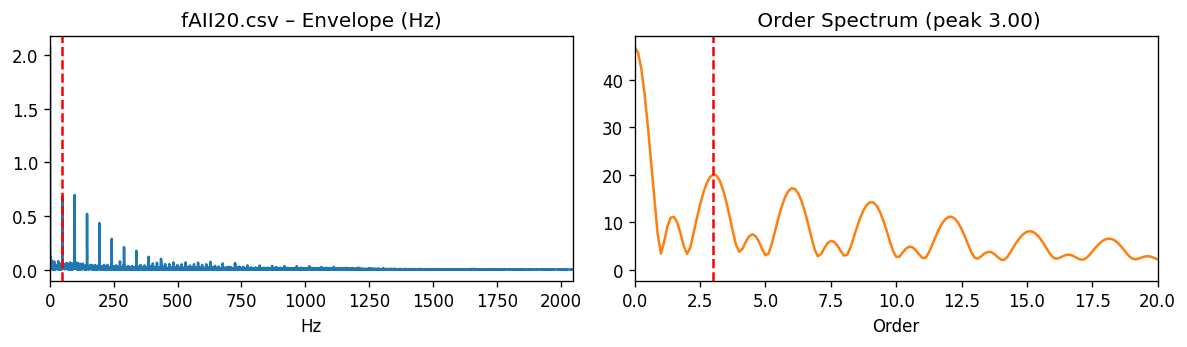

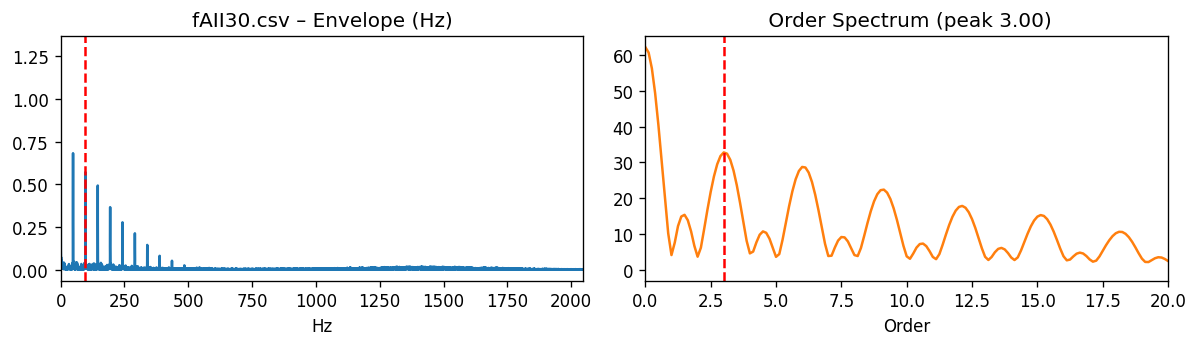

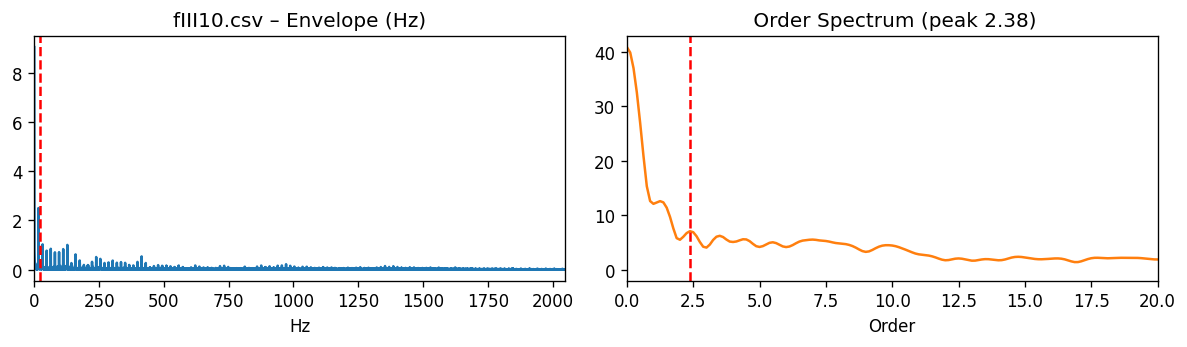

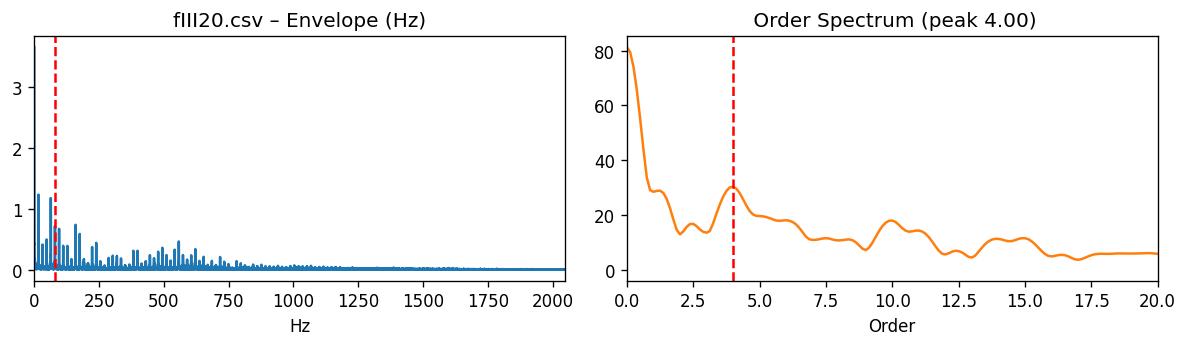

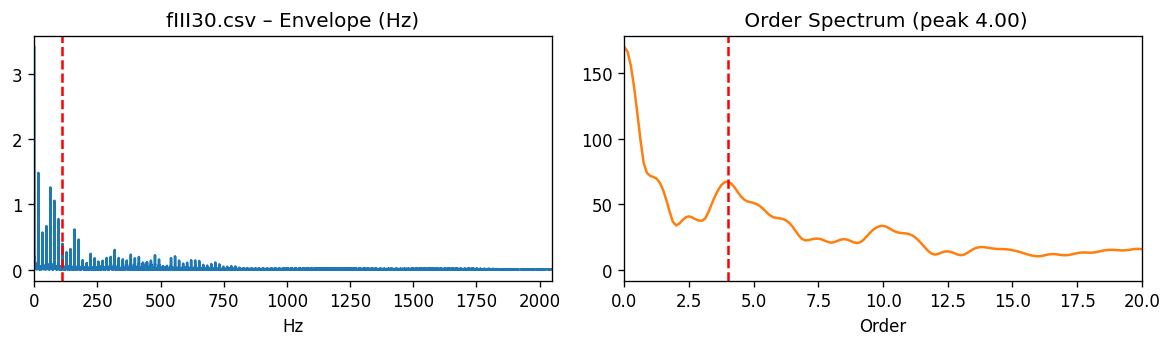

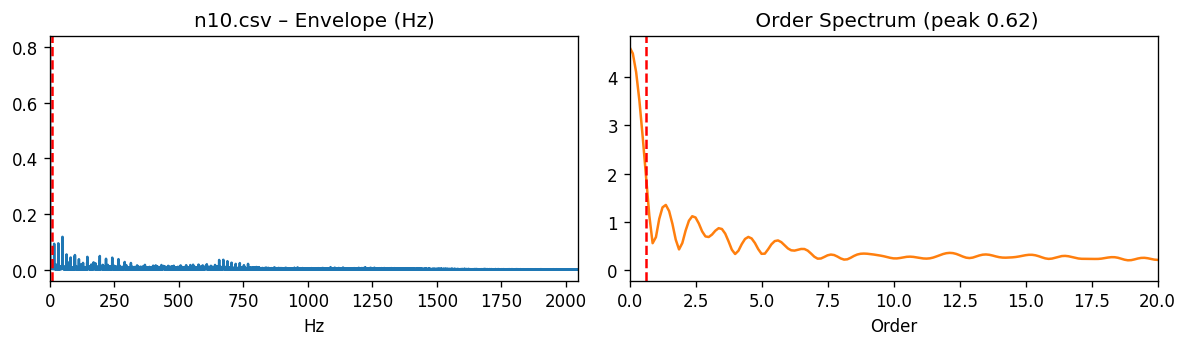

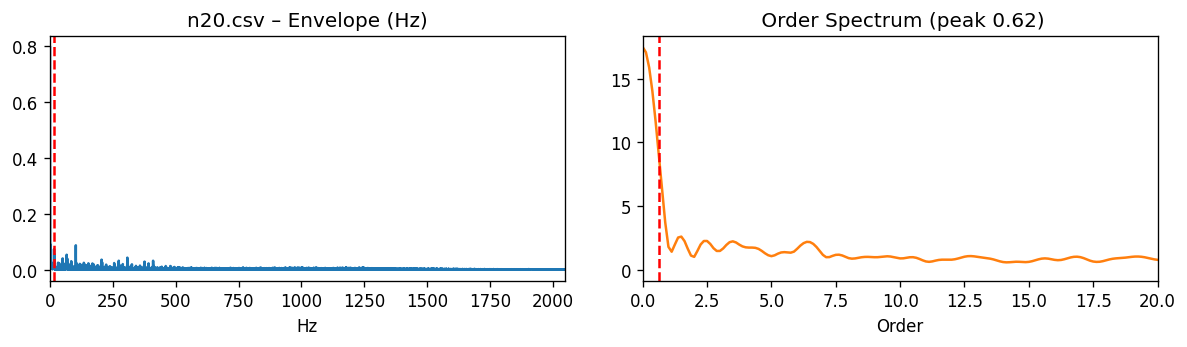

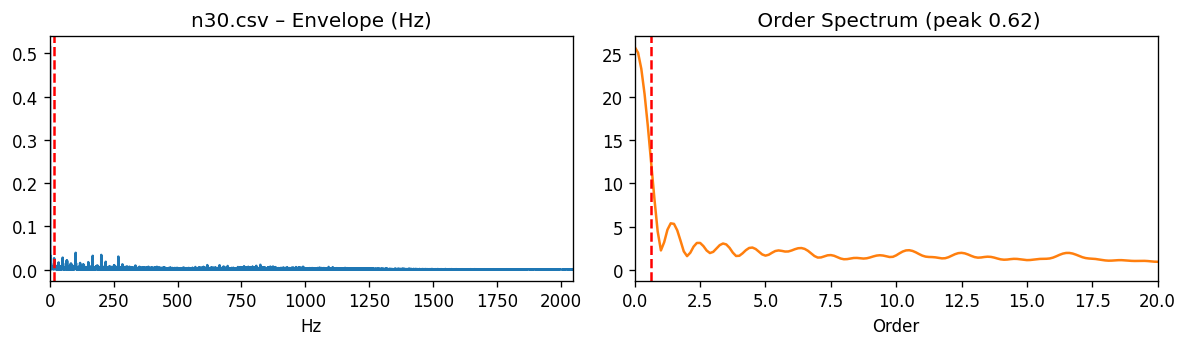

In [54]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt

from brf_lightning.data.bearing.utils import load_vibration_data
from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band

plt.rcParams["figure.dpi"] = 120

# ── CONFIG ───────────────────────────────────────────────────────────────
BASE_DIR       = Path("data/bearing_thl_v1")
N_ORD_SAMPLES  = 512          # angle‐bins per rev
NFFT_ORDER     = 4096         # FFT length for order‐spectrum
NFFT_ENV       = 65536        # FFT length for envelope spectrum
WINDOW_ENV     = np.hanning  # window for env‐FFT
NPERSEG_STFT   = 8192         # for spectral kurtosis
BANDWIDTH_HZ   = 2000.0       # SK search bandwidth
MIN_FREQ_HZ    = 100.0        # SK min freq
MAX_RATIO_NQ   = 0.95         # SK max ratio Nyquist

# ── FILENAME PARSING ────────────────────────────────────────────────────
speed_re  = re.compile(r"(\d+)\.csv$")
defect_re = re.compile(r"^(n|fAII|fIII)")

def parse_filename(fp):
    m1 = speed_re.search(fp.name)
    m2 = defect_re.match(fp.stem)
    return m2.group(1), float(m1.group(1))

# ── PHASE MAP ───────────────────────────────────────────────────────────
def build_phase_map(trig, fs):
    idx = np.flatnonzero(trig==1)
    n_full = (idx.size // 4)*4
    idx = idx[:n_full]
    revs = idx.reshape(-1,4)
    phi_t = np.zeros(len(trig), float)
    for s0, s1 in zip(revs[:-1,0], revs[1:,0]):
        L = s1 - s0
        phi_t[s0:s1] = np.linspace(0, 2*np.pi, L, endpoint=False)
    return phi_t, revs

# ── ANGULAR RESAMPLE ───────────────────────────────────────────────────
def angular_resample(x, phi_t, revs, M=N_ORD_SAMPLES):
    phi_bins = np.linspace(0, 2*np.pi, M, endpoint=False)
    out = []
    for s0, s1 in zip(revs[:-1,0], revs[1:,0]):
        seg_x   = x[s0:s1]
        seg_phi = phi_t[s0:s1]
        out.append(np.interp(phi_bins, seg_phi, seg_x))
    return np.vstack(out)

# ── ENVELOPE IN ANGLE DOMAIN ────────────────────────────────────────────
def envelope_angle(res, fs, f_lo, f_hi):
    # clamp
    f_lo = max(f_lo, 1.0)
    f_hi = min(f_hi, fs*0.5 - 1.0)
    if f_lo >= f_hi:
        f_lo = max(1.0, f_hi-1000.0)
        if f_lo >= f_hi:
            print("⚠️ SK band invalid; using [100 Hz → fs/2].")
            f_lo, f_hi = 100.0, fs*0.5 - 1.0
    sos = sig.butter(4, [f_lo, f_hi], btype='bandpass', fs=fs, output='sos')
    y = sig.sosfiltfilt(sos, res, axis=1)
    return np.abs(sig.hilbert(y, axis=1))

# ── ENVELOPE SPECTRUM (Hz) ──────────────────────────────────────────────
def compute_env_spectrum(env):
    flat = env.ravel() * WINDOW_ENV(env.size)
    spec = np.abs(np.fft.rfft(flat, n=NFFT_ENV))
    freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
    return freqs, spec

# ── ORDER SPECTRUM ──────────────────────────────────────────────────────
def compute_order_spectrum(env, M=N_ORD_SAMPLES):
    Y = np.fft.rfft(env, n=NFFT_ORDER, axis=1)
    orders = np.arange(Y.shape[1]) * (M/NFFT_ORDER)
    spec   = np.mean(np.abs(Y), axis=0)
    return orders, spec

# ── PEAK FINDER ─────────────────────────────────────────────────────────
def find_peak(x_axis, spec, center, window=0.3):
    lo, hi = center*(1-window), center*(1+window)
    idx = np.flatnonzero((x_axis>=lo)&(x_axis<=hi))
    i   = idx[np.argmax(spec[idx])]
    return x_axis[i], spec[i]

# ── THEORETICAL ORDER CENTERS ───────────────────────────────────────────
def outer_order(): return 4.95   # change to your actual BPFO/speed
def inner_order(): return 3.05   # change to your actual BPFI/speed

# ── PROCESS ONE FILE ────────────────────────────────────────────────────
def process_file(fp):
    defect, speed = parse_filename(fp)
    df, fs = load_vibration_data(fp)
    x   = df["sensor_bearing"].values
    trig= df["trig"].values.astype(int)

    # phase + resample
    phi_t, revs = build_phase_map(trig, fs)
    res         = angular_resample(x, phi_t, revs)

    # find SK band in time domain
    f, sk       = spectral_kurtosis(x, fs, nperseg=NPERSEG_STFT)
    f_lo, f_hi  = max_sk_band(f, sk, bandwidth=BANDWIDTH_HZ, min_freq=MIN_FREQ_HZ, max_ratio=MAX_RATIO_NQ)

    # envelope in angle domain
    env   = envelope_angle(res, fs, f_lo, f_hi)

    # spectra
    freqs, env_spec = compute_env_spectrum(env)
    orders, ord_spec= compute_order_spectrum(env, M=res.shape[1])

    # pick the right center
    center = outer_order() if defect=="fAII" else inner_order() if defect=="fIII" else 1.0

    # measure peaks
    meas_ord, mag_ord = find_peak(orders, ord_spec, center=center, window=0.4)
    meas_hz, mag_env  = find_peak(freqs, env_spec, center=meas_ord*speed, window=0.2)

    return {
        "file": fp.name,
        "defect": defect,
        "speed_Hz": speed,
        "theo_order": center,
        "meas_order": meas_ord,
        "mag_order": mag_ord,
        "meas_Hz": meas_hz,
        "mag_env": mag_env
    }

# ── RUN ALL & TABULATE ──────────────────────────────────────────────────
results = [process_file(fp) for fp in sorted(BASE_DIR.glob("*.csv"))]
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

# ── VISUALIZE EVERY CASE ────────────────────────────────────────────────
for row in results:
    fp = BASE_DIR/row["file"]
    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,3))
    df, fs = load_vibration_data(fp)
    x, trig = df["sensor_bearing"].values, df["trig"].values.astype(int)
    phi_t, revs = build_phase_map(trig, fs)
    res = angular_resample(x, phi_t, revs)
    env = envelope_angle(res, fs, *max_sk_band(*spectral_kurtosis(x, fs, nperseg=NPERSEG_STFT),
                                               bandwidth=BANDWIDTH_HZ, min_freq=MIN_FREQ_HZ, max_ratio=MAX_RATIO_NQ))

    f_env, s_env = compute_env_spectrum(env)
    ord_ax, s_ord= compute_order_spectrum(env, M=res.shape[1])

    ax1.plot(f_env, s_env, color='C0')
    ax1.axvline(row["meas_Hz"], color='r', ls='--')
    ax1.set_xlim(0, fs/4)
    ax1.set_title(f"{row['file']} – Envelope (Hz)")
    ax1.set_xlabel("Hz")

    ax2.plot(ord_ax, s_ord, color='C1')
    ax2.axvline(row["meas_order"], color='r', ls='--')
    ax2.set_xlim(0, 20)
    ax2.set_title(f" Order Spectrum (peak {row['meas_order']:.2f})")
    ax2.set_xlabel("Order")

    plt.tight_layout()
    plt.show()
